# Exploratory Data Analysis

The objective of this notebook is to explore the cleaned movie dataset and investigate how movie runtime relates to other variables such as release year, genres, ratings, popularity, and revenue.

Before performing the analysis, the runtime column will be validated to ensure that only reliable observations are included.

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

## Load Clean Dataset

In [50]:
data = pd.read_csv('data/interim.csv', low_memory=False)
data.head()

,budget,id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,collection,genre_names,company_names,country_names,language_names,release_year,release_decade
0,30000000.0,862.0,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,1995-10-30,373554033.0,81.0,Toy Story,7.7,5415.0,['Toy Story Collection'],"['Animation', 'Comedy', 'Family']",['Pixar Animation Studios'],['United States of America'],['English'],1995.0,1990.0
1,65000000.0,8844.0,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,1995-12-15,262797249.0,104.0,Jumanji,6.9,2413.0,NaN,"['Adventure', 'Fantasy', 'Family']","['TriStar Pictures', 'Teitler Film', 'Intersco...",['United States of America'],"['English', 'Français']",1995.0,1990.0
2,NaN,15602.0,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,1995-12-22,NaN,101.0,Grumpier Old Men,6.5,92.0,['Grumpy Old Men Collection'],"['Romance', 'Comedy']","['Warner Bros.', 'Lancaster Gate']",['United States of America'],['English'],1995.0,1990.0
3,16000000.0,31357.0,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,1995-12-22,81452156.0,127.0,Waiting to Exhale,6.1,34.0,NaN,"['Comedy', 'Drama', 'Romance']",['Twentieth Century Fox Film Corporation'],['United States of America'],['English'],1995.0,1990.0
4,NaN,11862.0,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,1995-02-10,76578911.0,106.0,Father of the Bride Part II,5.7,173.0,['Father of the Bride Collection'],['Comedy'],"['Sandollar Productions', 'Touchstone Pictures']",['United States of America'],['English'],1995.0,1990.0


## Dataset Overview

In [4]:
data.shape

(44977, 20)

In [5]:
data.head()

,budget,id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,collection,genre_names,company_names,country_names,language_names,release_year,release_decade
0,30000000.0,862.0,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",21.946943,/rhIRbceoE9lR4veEXuwCC2wARtG.jpg,1995-10-30,373554033.0,81.0,Toy Story,7.7,5415.0,['Toy Story Collection'],"['Animation', 'Comedy', 'Family']",['Pixar Animation Studios'],['United States of America'],['English'],1995.0,1990.0
1,65000000.0,8844.0,en,Jumanji,When siblings Judy and Peter discover an encha...,17.015539,/vzmL6fP7aPKNKPRTFnZmiUfciyV.jpg,1995-12-15,262797249.0,104.0,Jumanji,6.9,2413.0,NaN,"['Adventure', 'Fantasy', 'Family']","['TriStar Pictures', 'Teitler Film', 'Intersco...",['United States of America'],"['English', 'Français']",1995.0,1990.0
2,NaN,15602.0,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,11.712900,/6ksm1sjKMFLbO7UY2i6G1ju9SML.jpg,1995-12-22,NaN,101.0,Grumpier Old Men,6.5,92.0,['Grumpy Old Men Collection'],"['Romance', 'Comedy']","['Warner Bros.', 'Lancaster Gate']",['United States of America'],['English'],1995.0,1990.0
3,16000000.0,31357.0,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",3.859495,/16XOMpEaLWkrcPqSQqhTmeJuqQl.jpg,1995-12-22,81452156.0,127.0,Waiting to Exhale,6.1,34.0,NaN,"['Comedy', 'Drama', 'Romance']",['Twentieth Century Fox Film Corporation'],['United States of America'],['English'],1995.0,1990.0
4,NaN,11862.0,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,8.387519,/e64sOI48hQXyru7naBFyssKFxVd.jpg,1995-02-10,76578911.0,106.0,Father of the Bride Part II,5.7,173.0,['Father of the Bride Collection'],['Comedy'],"['Sandollar Productions', 'Touchstone Pictures']",['United States of America'],['English'],1995.0,1990.0


In [6]:
data.sample(5)

,budget,id,original_language,original_title,overview,popularity,poster_path,release_date,revenue,runtime,title,vote_average,vote_count,collection,genre_names,company_names,country_names,language_names,release_year,release_decade
36280,NaN,58725.0,hi,Netaji Subhas Chandra Bose: The Forgotten Hero,Netaji Subhas Chandra Bose: The Forgotten Hero...,0.388216,/wc2Z11hYoyRW9Y3NeVRzxGw2nIY.jpg,2005-05-13,NaN,222.0,Netaji Subhas Chandra Bose: The Forgotten Hero,8.0,1.0,NaN,"['Action', 'Drama', 'History']",NaN,NaN,"['বাংলা', 'हिन्दी', 'اردو']",2005.0,2000.0
19057,NaN,32050.0,en,The Black Windmill,A British agent's son is kidnapped and held fo...,1.266980,/A0B6MdCbxPbotliIJwotFb8dINH.jpg,1974-05-17,NaN,106.0,The Black Windmill,6.4,18.0,NaN,"['Thriller', 'Action', 'Crime']",['Universal Pictures'],['United Kingdom'],['English'],1974.0,1970.0
13493,NaN,16258.0,en,The Butterfly Effect 3: Revelations,The story revolves around a man trying to unco...,7.228413,/9LJfls07lQYeYctlbowaSgR4Rue.jpg,2009-01-09,NaN,90.0,The Butterfly Effect 3: Revelations,5.1,158.0,['The Butterfly Effect Collection'],"['Science Fiction', 'Thriller', 'Drama', 'Crime']","['FilmEngine', 'After Dark Films', 'BenderSpink']",['United States of America'],['English'],2009.0,2000.0
2935,700000.0,4203.0,es,Mujeres al borde de un ataque de nervios,Pepa resolves to kill herself with a batch of ...,5.470331,/lOehCiqghODNrNBpI1JS76zl6Lx.jpg,1988-03-14,7179298.0,88.0,Women on the Verge of a Nervous Breakdown,7.6,149.0,NaN,"['Comedy', 'Drama']",['El Deseo'],['Spain'],['Español'],1988.0,1980.0
40264,NaN,34745.0,en,Catch Me If You Can,"A hotshot, teenage car racer persuades the cla...",1.404418,/qfIz1V5HiuAQriJSgPlgVbovybB.jpg,1989-10-14,NaN,106.0,Catch Me If You Can,6.0,3.0,NaN,"['Action', 'Comedy', 'Drama']",NaN,NaN,['English'],1989.0,1980.0


In [7]:
import ast

columns_to_convert = ['collection', 'genre_names', 'company_names',
                       'country_names', 'language_names']

# Convert columns from string to list
for col in columns_to_convert:
    data[col] = data[col].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) and isinstance(x, str) else x)

# Verify the result
# Create a DataFrame to Verify the result
col_verify = pd.DataFrame({
    'Column': columns_to_convert,
    'Sample Value':  [data[col].iloc[0] for col in columns_to_convert],
    'Sample_Dtype': [type(data[col].iloc[0]) for col in columns_to_convert],
})
col_verify

,Column,Sample Value,Sample_Dtype
0,collection,[Toy Story Collection],<class 'list'>
1,genre_names,"[Animation, Comedy, Family]",<class 'list'>
2,company_names,[Pixar Animation Studios],<class 'list'>
3,country_names,[United States of America],<class 'list'>
4,language_names,[English],<class 'list'>


## Runtime Validation

Before exploring runtime patterns, we first verify that the runtime column is reliable for analysis. This includes identifying missing values, suspicious runtimes, and extreme observations. Only after validating the data quality will we proceed with the exploratory analysis.

In [8]:
runtime = data['runtime']
runtime.describe()

count    43231.000000
mean        97.531794
std         34.711792
min          1.000000
25%         86.000000
50%         95.000000
75%        107.000000
max       1256.000000
Name: runtime, dtype: float64

In [17]:
print(runtime.isna().sum())
print(runtime.isna().mean() * 100)

1746
3.8819841252195566


In [11]:
runtime.sort_values().head(10)

44961    1.0
44931    1.0
25030    1.0
19885    1.0
44237    1.0
39579    1.0
36248    1.0
36247    1.0
28376    1.0
40793    1.0
Name: runtime, dtype: float64

In [14]:
data.loc[
    data["runtime"] <= 10,
    ["title", "runtime", "release_year", "genre_names"]
].sort_values("runtime")

,title,runtime,release_year,genre_names
44961,The One-Man Band,1.0,1900.0,"['Fantasy', 'Action', 'Thriller']"
16165,The Four Troublesome Heads,1.0,1898.0,"['Comedy', 'Fantasy']"
16170,The Human Pyramid,1.0,1899.0,['Fantasy']
17236,Meat Love,1.0,1989.0,"['Comedy', 'Drama', 'Fantasy']"
17469,Edison Kinetoscopic Record of a Sneeze,1.0,1894.0,['Documentary']
...,...,...,...,...
38510,Multiple SIDosis,10.0,1970.0,NaN
38525,There Will Come Soft Rains,10.0,1984.0,"['Animation', 'Science Fiction']"
44658,Polygon,10.0,1977.0,['Animation']
44727,Rick and Morty: State of Georgia Vs. Denver Fe...,10.0,2016.0,"['Comedy', 'Crime']"


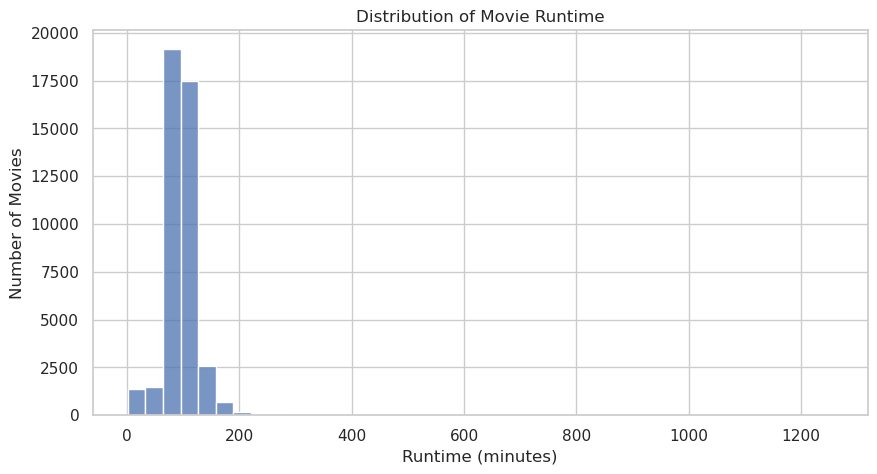

In [15]:
plt.figure(figsize=(10,5))
sns.histplot(data=data, x="runtime", bins=40)
plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [18]:
data.nlargest(
    20,
    "runtime"
)[["title", "runtime", "release_year", "genre_names"]]

,title,runtime,release_year,genre_names
24003,Centennial,1256.0,1978.0,"['Drama', 'History']"
19837,Jazz,1140.0,2001.0,['Documentary']
40543,Baseball,1140.0,1994.0,['Documentary']
13701,Berlin Alexanderplatz,931.0,1980.0,['Drama']
13885,Heimat: A Chronicle of Germany,925.0,1984.0,"['Drama', 'History']"
27649,The Story of Film: An Odyssey,900.0,2011.0,['Documentary']
26486,Taken,877.0,2002.0,['Science Fiction']
19042,The War,874.0,2007.0,"['Documentary', 'History', 'War']"
34364,The Roosevelts: An Intimate History,840.0,2014.0,"['History', 'Documentary']"
34429,Seventeen Moments in Spring,840.0,1973.0,"['Adventure', 'Drama', 'History', 'War']"


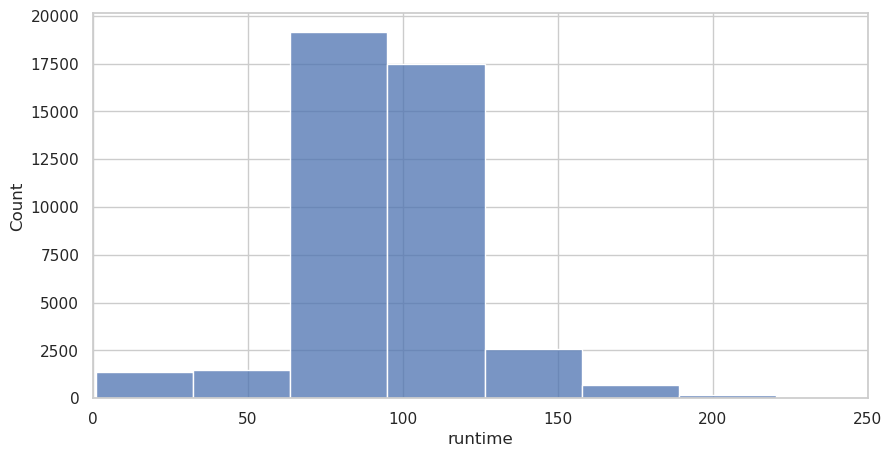

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=data,
    x="runtime",
    bins=40
)

plt.xlim(0,250)

plt.show()

### Runtime Distribution - Boxplot

A boxplot provides a compact summary of the runtime distribution and helps identify potential outliers.

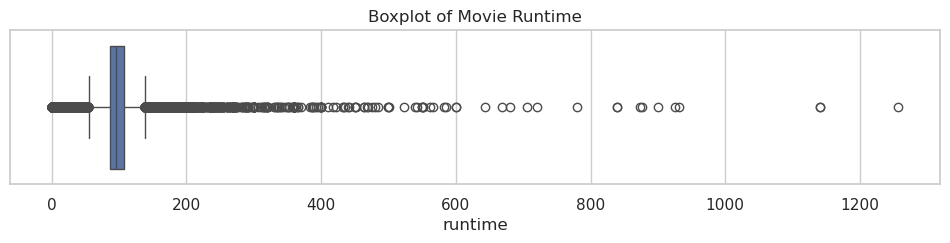

In [21]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=data,
    x="runtime"
)

plt.title("Boxplot of Movie Runtime")

plt.show()

In [44]:
print('count:', (data['runtime'] > 600).sum())
print('mean:', data[data['runtime'] > 600]['runtime'].mean())

count: 16
mean: 870.0625


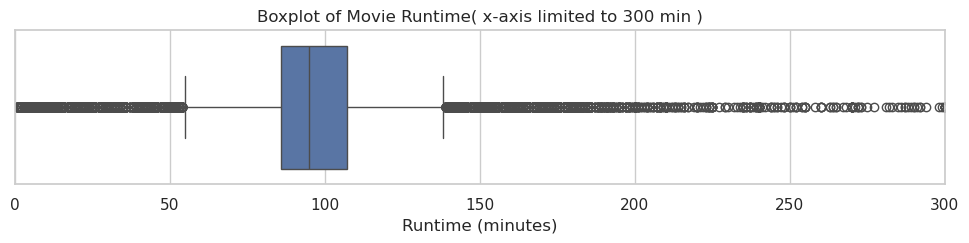

In [45]:
plt.figure(figsize=(12, 2))

sns.boxplot(
    data=data,
    x="runtime"
)
plt.xlim(0,300)
plt.xlabel("Runtime (minutes)")
plt.title("Boxplot of Movie Runtime( x-axis limited to 300 min )")

plt.show()

## Runtime Distribution

Now that the runtime column has been validated, we explore its overall distribution to understand the typical movie length and identify any notable patterns.

### Histogram with Kernel Density Estimation (KDE)

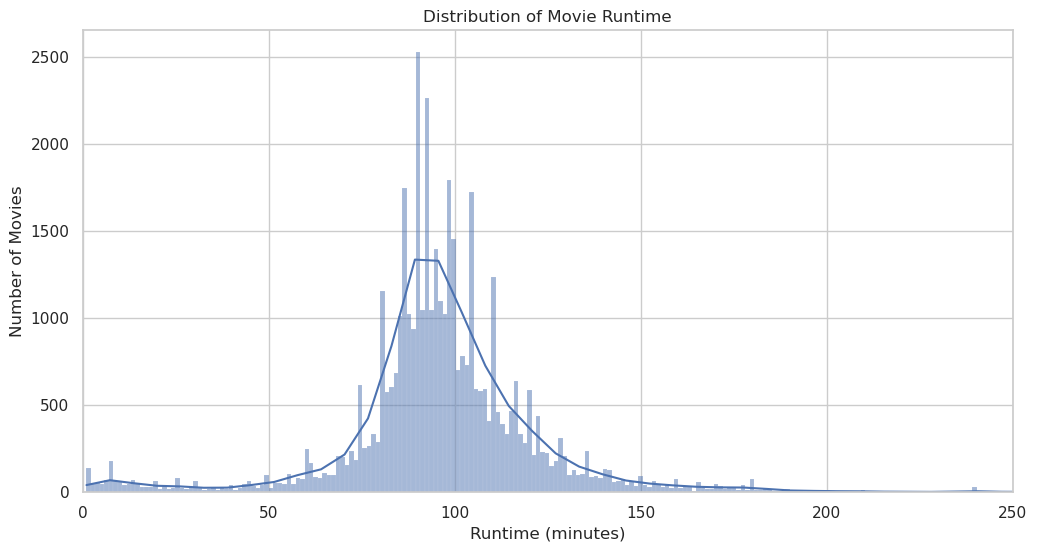

In [48]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=data,
    x="runtime",
    bins='auto',
    kde=True
)

plt.xlim(0, 250)

plt.title("Distribution of Movie Runtime")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Number of Movies")

plt.show()

The runtime distribution is unimodal, with a clear peak around 90–100 minutes. The distribution is right-skewed, indicating that while a small number of movies have exceptionally long runtimes, the vast majority fall between 80 and 120 minutes. This suggests that very long movies are rare and should be treated as exceptional cases rather than representative of the overall dataset.

> One of the motivations behind this project was the perception that most movies are around three hours long. However, the runtime distribution suggests otherwise. Most movies cluster around one and a half hours, while runtimes approaching three hours represent only a very small fraction of the dataset.

### Runtime Threshold Analysis

In [71]:
threshold = [90, 120, 150, 180, 240]
summary = []

for t in threshold:
    summary.append({
        "Runtime > (min)" : t,
        "Movies" : (runtime > t).sum(),
        "Percentage" : (runtime > t).mean() * 100
    }) 

runtime_summary = pd.DataFrame(summary)
runtime_summary

,Runtime > (min),Movies,Percentage
0,90,26962,59.946195
1,120,4976,11.063432
2,150,1384,3.077128
3,180,517,1.149476
4,240,195,0.433555


Although nearly 60% of movies are longer than 90 minutes, only about 1.15% exceed three hours (180 minutes), indicating that extremely long movies are uncommon.

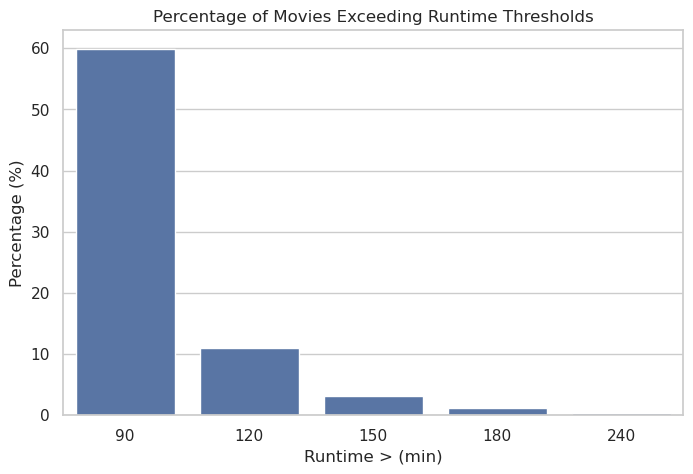

In [72]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=runtime_summary,
    x="Runtime > (min)",
    y="Percentage"
)

plt.title("Percentage of Movies Exceeding Runtime Thresholds")
plt.ylabel("Percentage (%)")

plt.show()

## Runtime Across Years
Has the average runtime of movies changed over time?

In [73]:
data["release_year"].describe()

count    44899.000000
mean      1991.819395
std         24.071299
min       1874.000000
25%       1978.000000
50%       2001.000000
75%       2010.000000
max       2017.000000
Name: release_year, dtype: float64

In [74]:
data["release_year"].isna().sum()

np.int64(78)

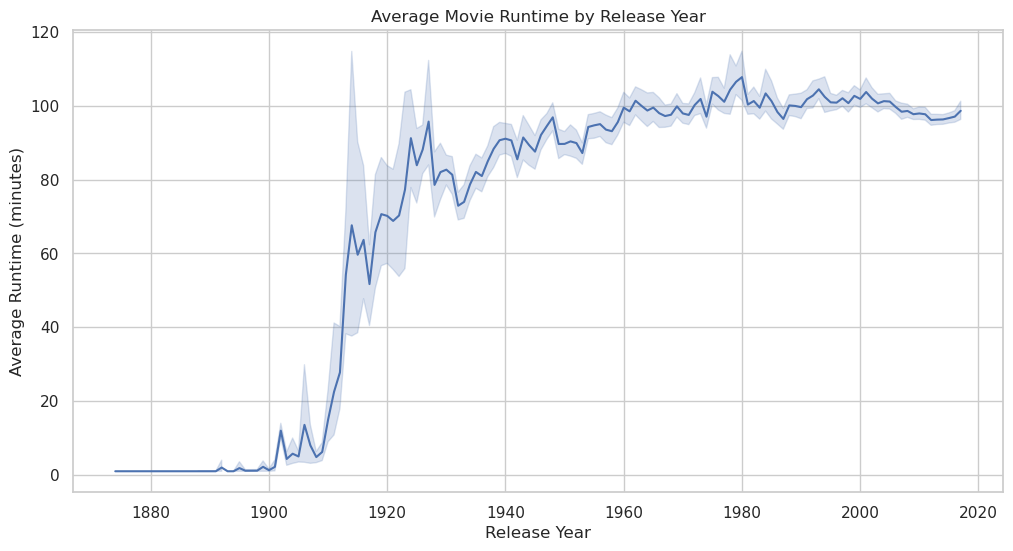

In [75]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=data,
    x="release_year",
    y="runtime"
)

plt.title("Average Movie Runtime by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Average Runtime (minutes)")

plt.show()

In [ ]:
runtime_by_year = (
    data
    .groupby("release_year")["runtime"]
    .mean()
    .reset_index()
)

runtime_by_year.head(10)

,release_year,runtime
0,1874.0,1.0
1,1878.0,1.0
2,1883.0,1.0
3,1887.0,1.0
4,1888.0,1.0


In [90]:
movies_per_year = (
    data.groupby("release_year")
    .size()
    .reset_index(name="movie_count")
)

movies_per_year.head(10)

,release_year,movie_count
0,1874.0,1
1,1878.0,1
2,1883.0,1
3,1887.0,1
4,1888.0,2
5,1890.0,5
6,1891.0,6
7,1892.0,3
8,1893.0,1
9,1894.0,13


In [91]:
valid_years = movies_per_year.loc[
    movies_per_year["movie_count"] >= 30,
    "release_year"
]

runtime_by_year_filtered = runtime_by_year[
    runtime_by_year["release_year"].isin(valid_years)
]

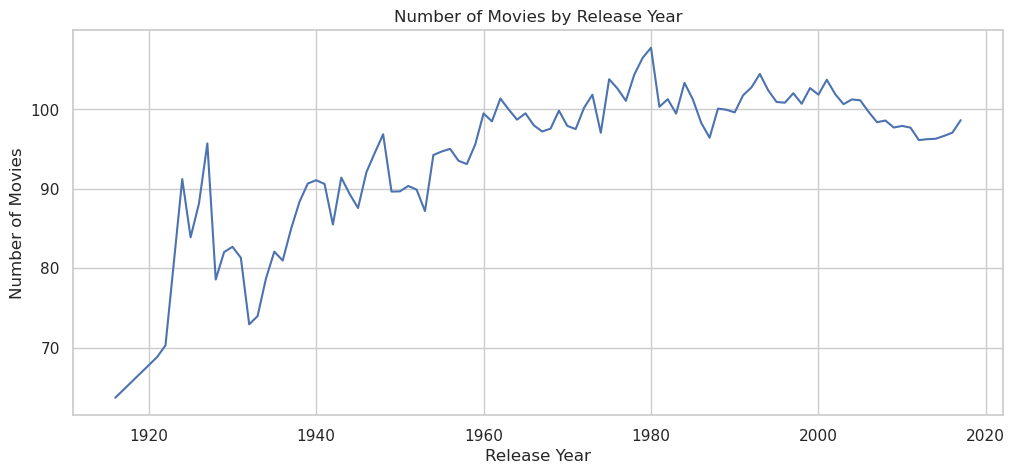

In [95]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=runtime_by_year_filtered,
    x="release_year",
    y="runtime"
)

plt.title("Number of Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")

plt.show()